# 医学分析：乳腺肿瘤良恶性二分类 (Wisconsin数据集)

## 1. 知识点简述

在医学临床评估中，针对肿瘤的**良恶性二分类**是最基础且关键的任务。

### 核心知识点：FNA (细针穿刺) 与手工形态学特征
当医生发现肿块时，常通过**细针穿刺 (Fine Needle Aspirate, FNA)** 获取细胞样本。通过显微图像，科研人员可以提取出描述细胞核特征的**手工特征 (Handcrafted Features)**，例如：
*   **半径 (Radius)**：结节中心到边缘的平均距离。
*   **纹理 (Texture)**：灰度值的标准差。
*   **平滑度 (Smoothness)**：半径长度局部变化的程度。
*   **凹陷度 (Concavity)**：边缘轮廓凹陷部分的程度。

### 威斯康星乳腺癌数据集 (WDBC)
这是机器学习领域最著名的三类医学数据集之一。它包含了真实采样的 569 个样本，每个样本有 30 个描述性特征。

## 2. 设计程序的意义
1.  **辅助决策**：通过机器学习算法，可以从数十个微小特征中发现人类肉眼难以发现的分类界限。
2.  **数据驱动诊断**：展示如何将“主观”的医学观察转化为“客观”的量化指标进行建模。
3.  **模型可解释性**：在医学领域，“为什么它是恶性的”比“它是恶性的”更重要。通过分析特征贡献，我们可以理解模型逻辑。

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 设置中文字体支持 (如果环境支持) 或绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid")

In [4]:
# 1. 加载 Scikit-learn 内置的真实乳腺癌数据集
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target # 0: 恶性 (Malignant), 1: 良性 (Benign)

print(f"数据集维度: {df.shape}")
print(f"类别分布:\n{df['Target'].value_counts()}")
print("\n前 5 行特征预览:")
display(df.head())

数据集维度: (569, 31)
类别分布:
Target
1    357
0    212
Name: count, dtype: int64

前 5 行特征预览:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. 探索性数据分析 (EDA)

在建模前，了解特征如何区分两类样本非常重要。我们选择两个关键特征（平均半径 vs 平均凹陷度）进行散点图观察。

> **观察重点**：恶性肿瘤（Target=0）通常具有更大的半径和更高的凹陷值。

d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20985 (\N{CJK UNIFIED IDEOGRAPH-51F9}) missing from font(s) Arial.
  

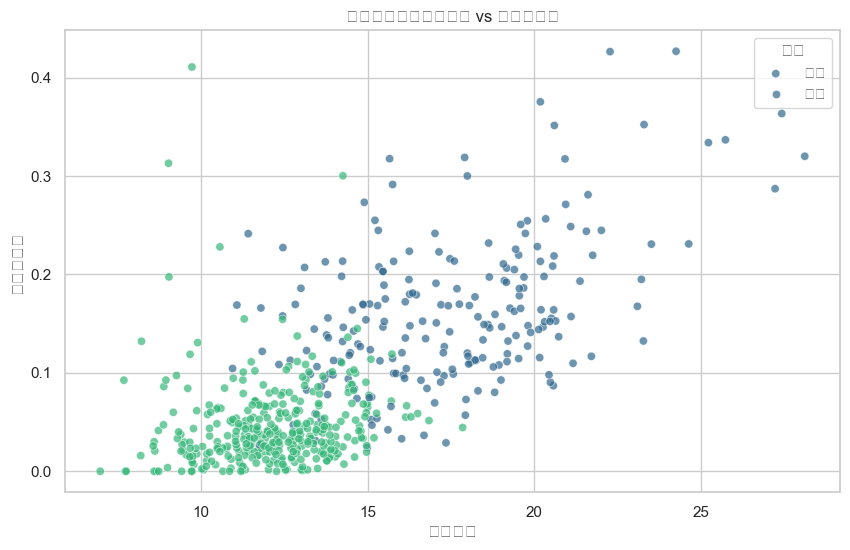

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mean radius', y='mean concavity', hue='Target', palette='viridis', alpha=0.7)
plt.title('特征散点图：平均半径 vs 平均凹陷度')
plt.xlabel('平均半径')
plt.ylabel('平均凹陷度')
plt.legend(title='诊断', labels=['恶性', '良性'])
plt.show()

## 4. 数据预处理

由于不同特征的数值范围差异很大（例如半径在 10-20 左右，而面积可能达到 1000 以上），我们必须进行**标准化 (Standardization)**。

标准化公式：
$$z = \frac{x - \mu}{\sigma}$$

这将确保所有特征的均值为 0，标准差为 1，从而让机器学习模型（如 SVM）收敛更快。

In [6]:
X = data.data
y = data.target

# 划分训练集和测试集 (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 执行标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"标准化后的训练集形状: {X_train_scaled.shape}")
print(f"特征 1 的均值: {X_train_scaled[:, 0].mean():.2f}")
print(f"特征 1 的标准差: {X_train_scaled[:, 0].std():.2f}")

标准化后的训练集形状: (455, 30)
特征 1 的均值: -0.00
特征 1 的标准差: 1.00


## 5. 建立 SVM 分类模型

支持向量机 (SVM) 在小规模医学数据集上表现非常稳健。它试图在该维度空间中找到一个“最宽”的街道，将良性和恶性样本隔开。

我们将设置 `probability=True`，这样模型不仅能给出分类，还能给出**恶性概率预测**。

In [7]:
# 创建 SVM 实例，使用径向基核 (RBF)
model = SVC(kernel='rbf', probability=True, random_state=42)

# 训练模型
model.fit(X_train_scaled, y_train)

# 进行预测
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("模型训练已完成。")

模型训练已完成。


## 6. 模型评估

在医学诊断中，**假阴性 (False Negative)** —— 即把恶性识别为良性 —— 是绝对不能容忍的。因此，我们除了看准确率 (Accuracy)，更要关注**召回率 (Recall)**。

我们将通过混淆矩阵和 ROC 曲线来评估模型。

分类报告:
              precision    recall  f1-score   support

          恶性       1.00      0.95      0.98        43
          良性       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Arial.
  fig.canvas.draw()
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Arial.
  fig.canvas.draw()
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24694 (\N{CJK UNIFIED IDEOGRAPH-6076}) missing from font(s) Arial.
  fig.canvas.draw()
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  fig.canvas.draw()
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) Arial.
  fig.canvas.draw()
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}

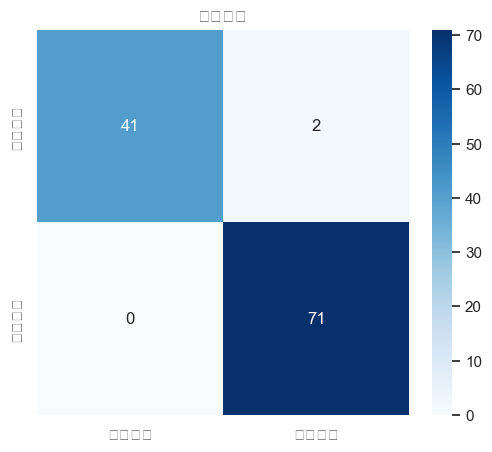

d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20551 (\N{CJK UNIFIED IDEOGRAPH-5047}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38451 (\N{CJK UNIFIED IDEOGRAPH-9633}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  

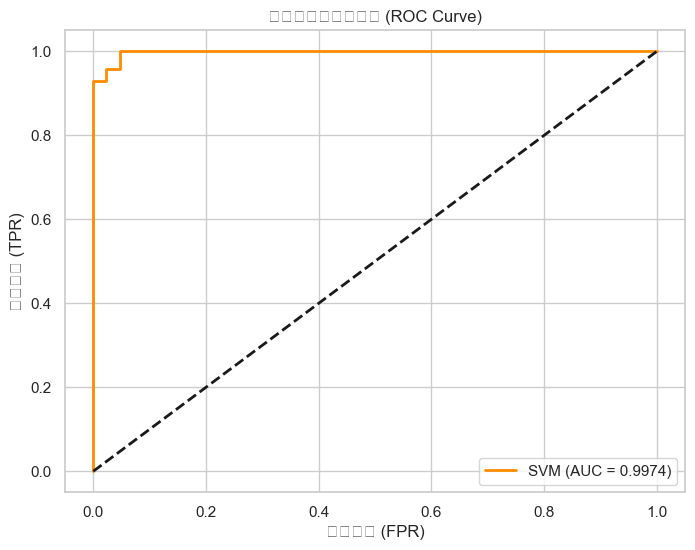

In [8]:
# 1. 打印详细分类报告
print("分类报告:")
print(classification_report(y_test, y_pred, target_names=['恶性', '良性']))

# 2. 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['预测恶性', '预测良性'], 
            yticklabels=['真实恶性', '真实良性'])
plt.title('混淆矩阵')
plt.show()

# 3. 绘制 ROC 曲线与计算 AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc_val:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('假阳性率 (FPR)')
plt.ylabel('真阳性率 (TPR)')
plt.title('接收者操作特征曲线 (ROC Curve)')
plt.legend()
plt.show()

---

## 7. 拓展、思考与总结

本案例演示了如何利用标准化的真实医学特征数据集通过 SVM 实现肿瘤良恶性分类。

### 🎓 学生思考题

#### 思考题 1：关于标准化 (Scaling)
**问题**：观察模型评估结果，如果我们在代码中注释掉 `StandardScaler` 相关的两行代码，再次运行，准确率和混淆矩阵会发生什么变化？为什么？
*   **解答思路**：SVM 对特征的数值大小非常敏感。如果某个特征（如面积）数值特别大，它在损失函数计算中会占据主导权重，导致其他细微但关键的特征（如边缘凹陷度）被忽略，性能会显著下降。

#### 思考题 2：特征贡献分析
**问题**：如果你需要向医生解释哪些特征最能区分样本，你会使用什么方法？
*   **解答思路**：可以尝试将 `SVC` 更换为线性核 `kernel='linear'`，然后查看 `model.coef_`；或者使用随机森林 (Random Forest) 的 `feature_importances_` 指标。

#### 思考题 3：漏诊风险与阈值调整
**问题**：在目前的混淆矩阵中，如果我们发现仍有“假阴性”（恶性被判良性），除了收集更多数据，我们在代码应用层面可以如何调整？
*   **解答思路**：调整分类阈值。目前默认以概率 0.5 作为分界点。由于漏诊恶性的代价极大，我们可以将阈值调低（例如 0.2），牺牲一部分精确度来最大化召回率。
